In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("salader/dogsvscats")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'dogsvscats' dataset.
Path to dataset files: /kaggle/input/dogsvscats


### Exploring the Dataset Structure
Now that the dataset is downloaded, let's look at the folders and files available at the path provided by `kagglehub`.

In [ ]:
import os

# List the contents of the dataset path
for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 4 * (level + 1)
    # Limit file printing for clarity
    for f in files[:3]:
        print(f'{subindent}{f}')
    if len(files) > 3:
        print(f'{subindent}...')

dogsvscats/
    test/
        dogs/
            dog.375.jpg
            dog.704.jpg
            dog.8597.jpg
            ...
        cats/
            cat.8762.jpg
            cat.7083.jpg
            cat.9820.jpg
            ...
    train/
        dogs/
            dog.3443.jpg
            dog.7971.jpg
            dog.10728.jpg
            ...
        cats/
            cat.12461.jpg
            cat.10176.jpg
            cat.8194.jpg
            ...
    catsvsdogs/
        test/
            dogs/
                dog.375.jpg
                dog.704.jpg
                dog.8597.jpg
                ...
            cats/
                cat.8762.jpg
                cat.7083.jpg
                cat.9820.jpg
                ...
        train/
            dogs/
                dog.3443.jpg
                dog.7971.jpg
                dog.10728.jpg
                ...
            cats/
                cat.12461.jpg
                cat.10176.jpg
                cat.8194.jpg
                ...


### Loading a Sample Image
To ensure we can access the data, let's try to display one of the images from the dataset.

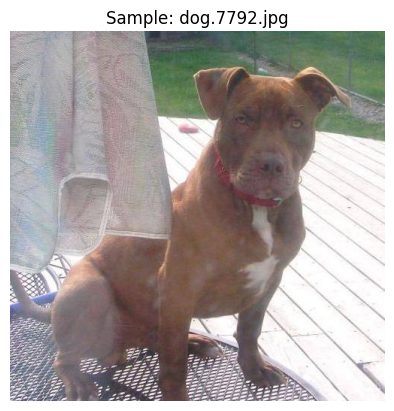

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import glob

# Find all jpg files in the path recursively
image_files = glob.glob(f'{path}/**/*.jpg', recursive=True)

if image_files:
    img_path = image_files[12]
    img = mpimg.imread(img_path)
    plt.imshow(img)
    plt.title(f"Sample: {os.path.basename(img_path)}")
    plt.axis('off')
    plt.show()
else:
    print("No image files found in the directory.")

In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
import numpy as np
import pandas as pd


In [ ]:
image_files[0]

'/kaggle/input/dogsvscats/test/dogs/dog.375.jpg'

In [ ]:
from keras.layers import Dense,Conv2D,Flatten,GlobalMaxPooling1D

In [ ]:
# generators - pura data ek sath load nahi ho sakti to thoda thoda data load hoga
# loads on batch after that batch removed and then new added

train_ds=keras.utils.image_dataset_from_directory(
    directory='/kaggle/input/dogsvscats/train',
    labels="inferred",
    label_mode="int",#dog=0 , cat = 1
    batch_size=32,
    image_size=(256, 256),
    validation_split=None,
    subset=None,
    verbose=True,
)

test_ds=keras.utils.image_dataset_from_directory(
    directory='/kaggle/input/dogsvscats/test',
    labels="inferred",
    label_mode="int",#dog=0 , cat = 1
    batch_size=32,
    image_size=(256, 256),
    validation_split=None,
    subset=None,
    verbose=True,
)


Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


## now we need to normalize the pixels of image : 0-256 hame kai baar training me dikkat de sakta hai to ham normalize karne ke liye function likhenege

In [ ]:
def normalize(image,label):
  image=tf.cast(image/255,tf.float32)
  return image,label

train_ds=train_ds.map(normalize)
test_ds=test_ds.map(normalize)

Here is how .map() works behind the scenes:

.map() tells Python: "Go through train_ds one item at a time."

Since every item in train_ds is an (image, label) tuple, .map() automatically grabs that tuple.

It invisibly feeds that tuple into your normalize function.

It takes the result and builds a brand new, updated dataset.

### Every Image in machine learning or deep laerning appication mostly contains image and label so we did the mapping and the the deep learning alogrithms needs accurate number thats why we converted them into float which will help to make the calculations .  

In [ ]:
from keras.layers import MaxPooling2D

In [ ]:
# model=Sequential()

# model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))
# model.add(MaxPooling2D(pool_size=(2, 2), strides=None, padding='valid'))

# model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu'))
# model.add(MaxPooling2D(pool_size=(2, 2), strides=None, padding='valid'))

# model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu'))
# model.add(MaxPooling2D(pool_size=(2, 2), strides=None, padding='valid'))

# model.add(Flatten())

# model.add(Dense(128,activation='relu'))
# model.add(Dense(64,activation='relu'))
# model.add(Dense(1,activation='sigmoid'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 28800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,686,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,714,241 (14.17 MB)

 Trainable params: 3,714,241 (14.17 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# model.compile(loss='binary_crossentropy',optimizer='Adam',metrics=['accuracy'])

In [ ]:
# history = model.fit(train_ds,epochs=10,validation_data=test_ds)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 65ms/step - accuracy: 0.9923 - loss: 0.0229 - val_accuracy: 0.7614 - val_loss: 1.5061
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 63ms/step - accuracy: 0.9926 - loss: 0.0223 - val_accuracy: 0.7694 - val_loss: 1.4574
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 68ms/step - accuracy: 0.9919 - loss: 0.0271 - val_accuracy: 0.7720 - val_loss: 1.4803
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 65ms/step - accuracy: 0.9911 - loss: 0.0268 - val_accuracy: 0.7746 - val_loss: 1.5251
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 39s 63ms/step - accuracy: 0.9929 - loss: 0.0244 - val_accuracy: 0.7748 - val_loss: 1.4326
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 39s 63ms/step - accuracy: 0.9958 - loss: 0.0136 - val_accuracy: 0.7702 - val_loss: 1.6806
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 39s 63ms/step - accuracy: 0.9956 - loss: 0.0140 - val_accuracy: 0.7772 - val_loss: 1.7078
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 39s 63ms/step - accuracy: 0.9952 - loss: 0.0171 - 

In [ ]:
# history.history

{'accuracy': [0.9922500252723694,
  0.9926499724388123,
  0.9919000267982483,
  0.991100013256073,
  0.9928500056266785,
  0.9958000183105469,
  0.9955999851226807,
  0.995199978351593,
  0.998199999332428,
  0.996399998664856],
 'loss': [0.02287711761891842,
  0.0223329346626997,
  0.02708224579691887,
  0.026820315048098564,
  0.024386487901210785,
  0.013635329902172089,
  0.01404405478388071,
  0.017069874331355095,
  0.0062565370462834835,
  0.012206700630486012],
 'val_accuracy': [0.7613999843597412,
  0.7694000005722046,
  0.7720000147819519,
  0.7746000289916992,
  0.7748000025749207,
  0.7702000141143799,
  0.7771999835968018,
  0.776199996471405,
  0.7717999815940857,
  0.760200023651123],
 'val_loss': [1.50611412525177,
  1.4573904275894165,
  1.4803128242492676,
  1.5251103639602661,
  1.4326460361480713,
  1.680556058883667,
  1.7077786922454834,
  1.6714056730270386,
  1.8828859329223633,
  1.721253514289856]}

In [ ]:
import matplotlib.pyplot as plt

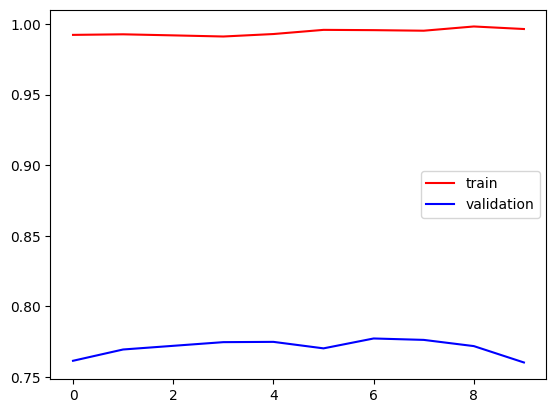

In [ ]:
# plt.plot(history.history['accuracy'],color='red',label='train')
# plt.plot(history.history['val_accuracy'],color='blue',label='validation')
# plt.legend()
# plt.show()

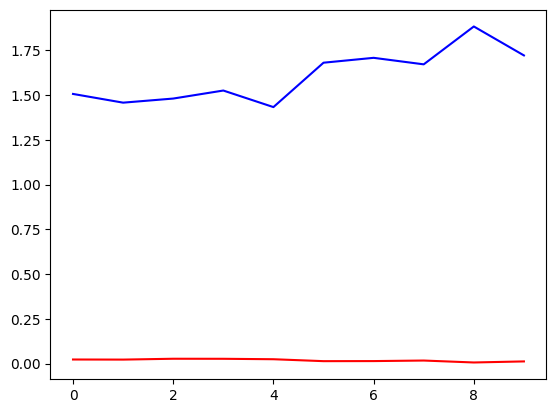

In [ ]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')


  ### ways to reduce overfitting

  1. data augmentation
  2. l1/l2 regularization
  3. dropout
  4. batch norm
  5. add more data
  6. reduce complexity

In [ ]:
from keras.layers import BatchNormalization,Dropout

In [ ]:
model=Sequential()

model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2), strides=None, padding='valid'))

model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2), strides=None, padding='valid'))

model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2), strides=None, padding='valid'))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(1,activation='sigmoid'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(loss='binary_crossentropy',optimizer='Adam',metrics=['accuracy'])

In [35]:
history =model.fit(train_ds,epochs=10,validation_data=test_ds)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 54s 76ms/step - accuracy: 0.6489 - loss: 0.6566 - val_accuracy: 0.6360 - val_loss: 0.6137
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 46s 74ms/step - accuracy: 0.7232 - loss: 0.5404 - val_accuracy: 0.6946 - val_loss: 0.5671
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 47s 75ms/step - accuracy: 0.7647 - loss: 0.4835 - val_accuracy: 0.7658 - val_loss: 0.5008
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 78s 69ms/step - accuracy: 0.8070 - loss: 0.4096 - val_accuracy: 0.7850 - val_loss: 0.4629
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 46s 74ms/step - accuracy: 0.8413 - loss: 0.3427 - val_accuracy: 0.7700 - val_loss: 0.4751
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 73ms/step - accuracy: 0.8663 - loss: 0.2944 - val_accuracy: 0.7828 - val_loss: 0.4918
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 43s 69ms/step - accuracy: 0.8881 - loss: 0.2463 - val_accuracy: 0.7840 - val_loss: 0.6201
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 70ms/step - accuracy: 0.9039 - loss: 0.2101 - 

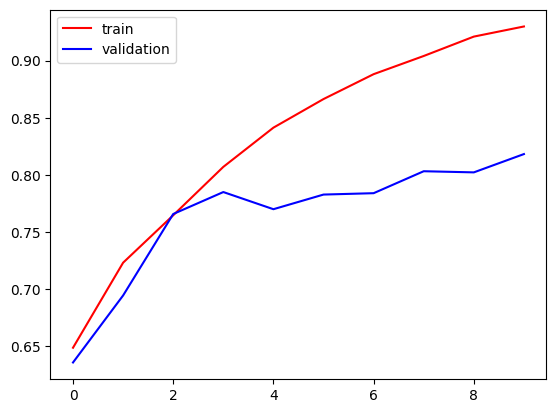

In [36]:
plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

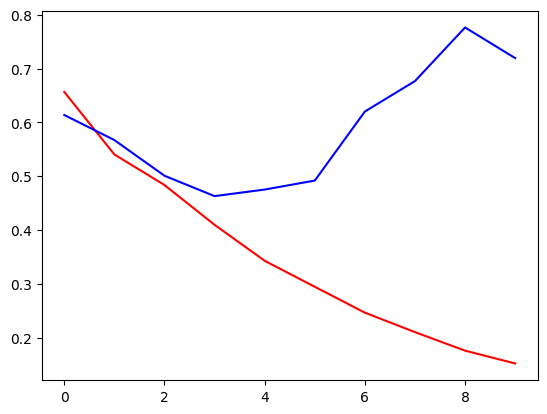

In [37]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')


In [38]:
import cv2

In [39]:
test_img=cv2.imread('/content/dog.jpg')

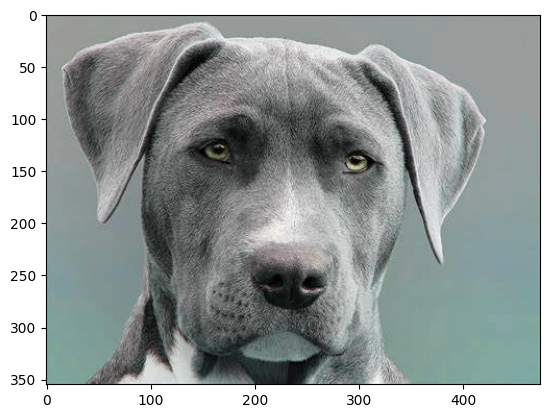

In [40]:
plt.imshow(test_img)

In [41]:
test_img.shape

(355, 474, 3)

In [42]:
test_img=cv2.resize(test_img,(256,256))

In [43]:
test_input=test_img.reshape((1,256,256,3))

In [44]:
model.predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


array([[6.353329e-17]], dtype=float32)